# Correlational and Onset Analysis
This section examines if, how and where running speed or running onsets correlate with neural activity in terms of extracted spikes via oasis

In [1]:
from utils.utils import *

In [2]:
data = load_saved_data("data_with_spikes_and_speed_new")

# Running speed - Spike Correlations

#### Compute Running - Spike Correlations
This analysis requires three main steps:
1) extracting the phases in which no stimulus was shown, as we don't want to capture stimulus-driven effects influence either on neural activity or running speed (e.g. predator image)
2) Downsampling the (continuous) data to increase the strength of possible effects
3) Applying statistical methods to identify possible modulators effects of running. For this, we look at pearson (and spearman) correlations and the explained variance of a simple linear regression

The method 'perform_running_modulation_analysis' performs all three steps for each neuron of each session.

Note: session C contains substantially less spontaneous data (and later on onset data) compared to session A and B which is why the interpretation will mainly focus on the results of sessions A and B, although sessions Cs results are included.

In [3]:
results, binned_data = perform_running_modulation_analysis(data)
for name, session in data["sessions"].items():
    print(name)
    print(results[name].describe())

C
          neuron  pearson_r  spearman_rho      slope  intercept            r2
count  47.000000  47.000000     47.000000  47.000000  47.000000  4.700000e+01
mean   23.000000   0.012669      0.004698   0.003161   0.009388  2.019495e-03
std    13.711309   0.043582      0.015398   0.015186   0.022318  6.799387e-03
min     0.000000  -0.018939     -0.017450  -0.015221   0.000098  2.280737e-09
25%    11.500000  -0.008207     -0.005919  -0.000199   0.000345  1.352076e-05
50%    23.000000  -0.000052      0.001384  -0.000002   0.001019  1.143002e-04
75%    34.500000   0.014305      0.012499   0.000172   0.004765  2.959427e-04
max    46.000000   0.177603      0.045689   0.072719   0.114172  3.154278e-02
B
          neuron  pearson_r  spearman_rho      slope  intercept         r2
count  47.000000  47.000000     47.000000  47.000000  47.000000  47.000000
mean   23.000000  -0.017339     -0.005239  -0.000409   0.021988   0.018490
std    13.711309   0.136326      0.145420   0.002472   0.065272   0.0

As the preview of the data already suggests, there is high variablity between neurons with no substantial mean correlation over all neurons (between -.001 and +.002) but also neurons that show mild negative correlations and some that show strong positive correlations (between -0.3 to + 0.63; session B). The next block will investigate this distribution and the individual neuron's correlations and mean running speed modulations further.

### Running correlation plots

First we can look at the distribution of (pearson) correlations, to see what drives the variability. For this, we can visualize the data
1) as histogram and
2) with the neurons sorted by correlation strength

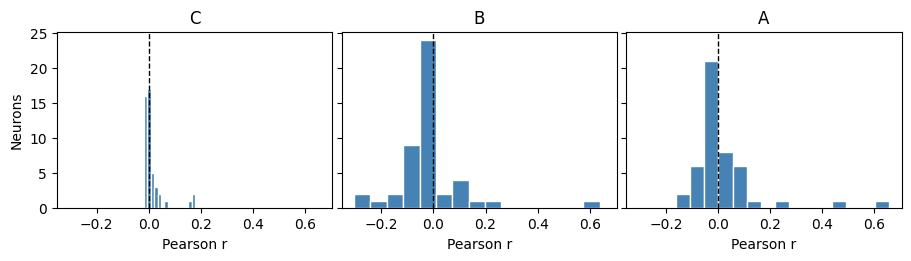

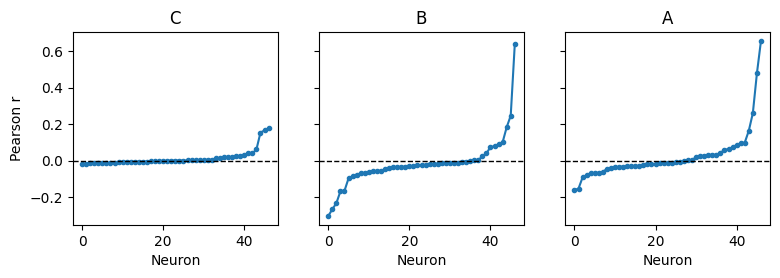

In [4]:
plot_correlation_histograms(results)
plot_running_correlations(results)


We can see, that most neuron's activity is not/barely positively or negatively correlated with running speed, which results in a distribution around 0. However, there is a small number of strong outliers, most notably is neuron 25 (the one with the highest positive correlation of >.63 in session A and B)

To investigate the speed modulation in general population further, we can plot the result of the linear regression (red curve) and the mean activity for different running speeds (blue curve) for all neurons.

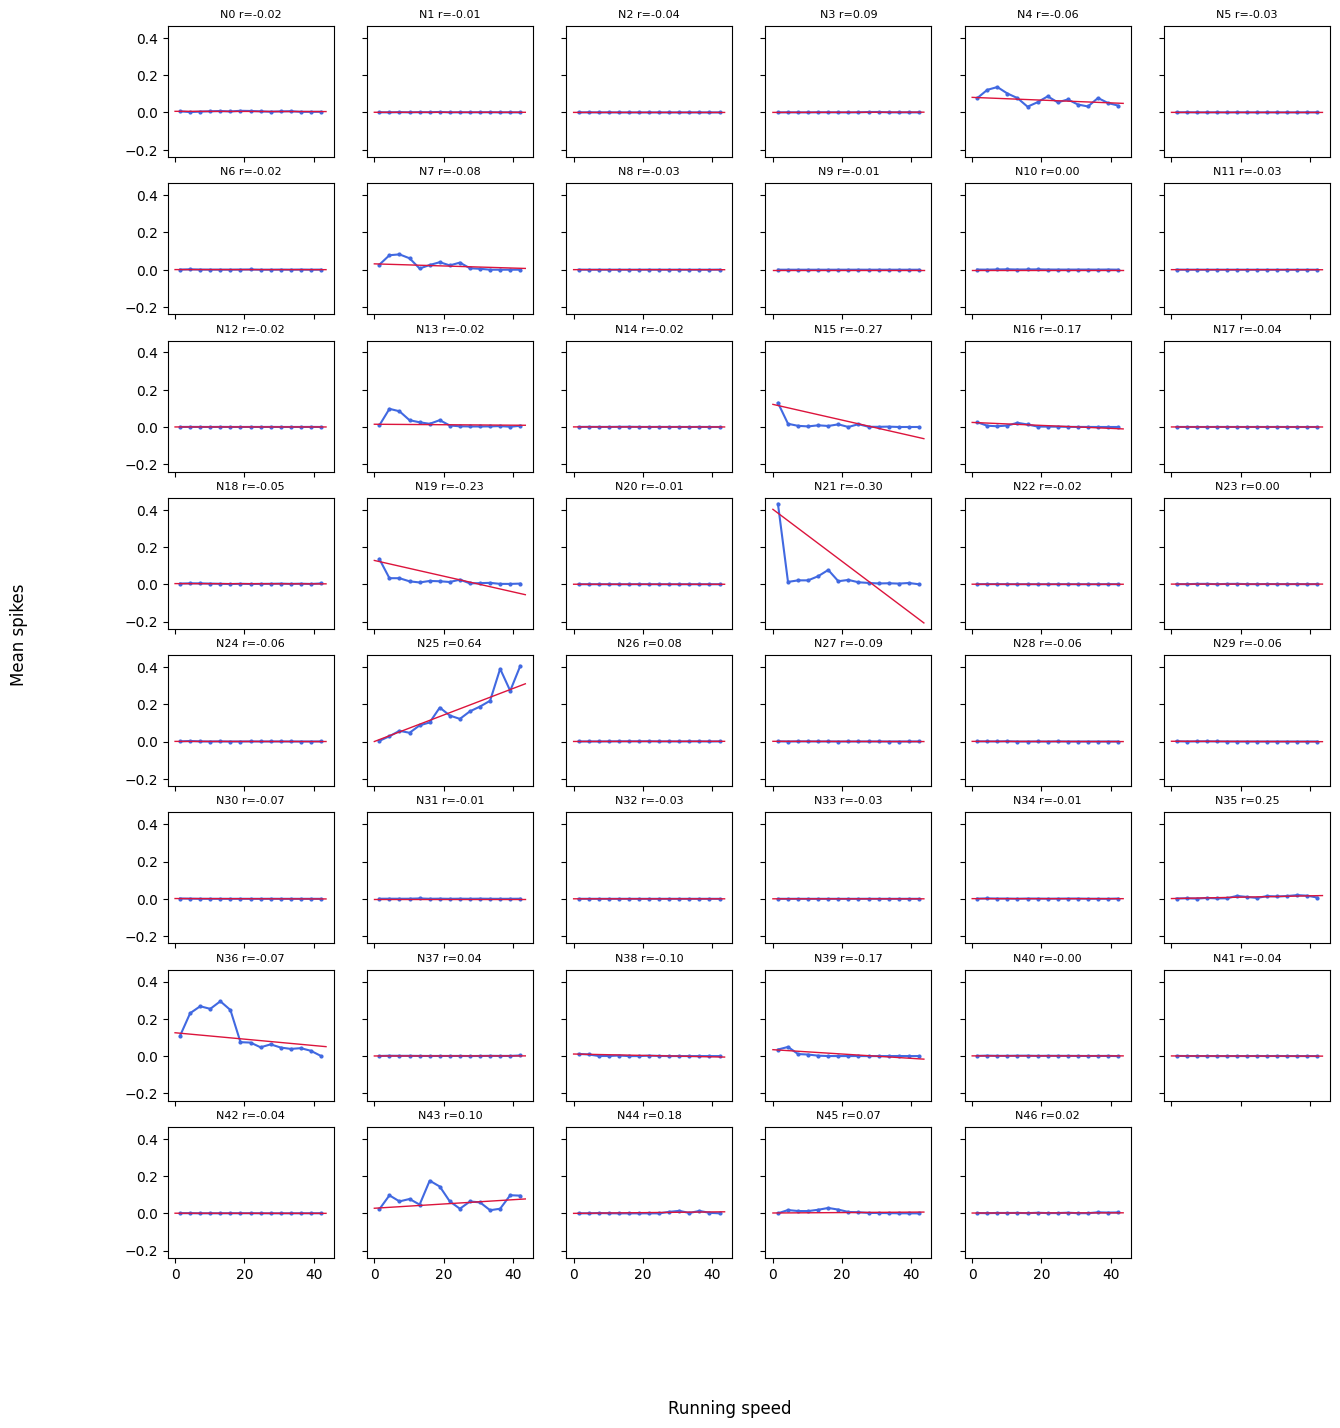

In [5]:
plot_running_modulation_all(binned_data, results, "B")

As expected, most of the neurons have flat curves, while others either increase their activation with increase speed (e.g. neuron 25), or fall back to almost zero firign rate which suggests that there might be an effect of surpression. Neuron 36 shows interesting behaviour in session B, where speed increase first increases neural activity but then it falls off again. This behaviour is partially reflected in session A. While this could be noise due to the small dataset, this might also be reflecting onset behaviour, as a mouse first increases the speed to reach higher speed levels.

To visualy examine the regression result and the speed modulation for the strongest influenced neuron (25) further, we can plot it with datapoints included.

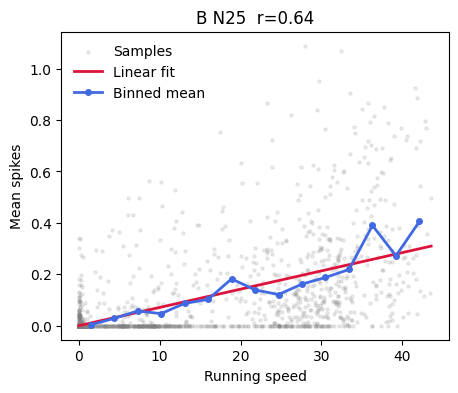

In [6]:
plot_running_modulation_neuron(binned_data, results, "B", 25)

As a sanity check, if the correlations stay stable across the sessions, we can plot this. (Note, session C data is sparse)

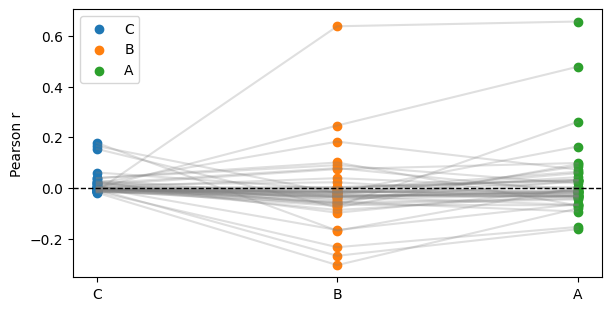

In [8]:
plot_running_correlation_sessions(results)

While there are differences between sessions, the direction and magnitude seem to be mostly consistent.

# Running Onset Modulation

#### Compute Running Onset - Spike Correlations
Similar to the above analysis, examining the onset also requires extraction of the relevant data and evaluating it ststistically.
This analysis requires three main steps:
1) Identifying running onsets, which means identifying sufficiently long below-threshold still phases followed by sufficiently long above-threshold running phases.
2) Extracting windows around the onsets
3) Applying statistical methods to identify possible modulators effects of running. For this, we compute the mean diff between the phase before onset and the phase after onset and test this via a sign-flip permutation test.

The method 'perform_onset_modulation_analysis' performs all three steps for each neuron of each session.

### Compute Onset Modulation

In [9]:
onset_results, onset_data = perform_onset_modulation_analysis(data)
for name, df in onset_results.items():
    print(name, "events:", df.n_events.iloc[0], "neurons:", len(df))

C events: 2 neurons: 47
B events: 37 neurons: 47
A events: 61 neurons: 47


The small number of occurrences limits the interpretation, especially for session C.

Some neurons reached significance in the permutation test:

In [10]:
for name, df in onset_results.items():
    sig = df[(df.p < 0.05) & (df.delta > 0)]
    print(name)
    print(sig[["neuron", "delta", "p"]])

C
    neuron     delta       p
18      18  0.003805  0.0001
25      25  0.001255  0.0001
37      37  0.006924  0.0001
B
    neuron     delta         p
0        0  0.002155  0.007999
4        4  0.030844  0.048795
23      23  0.002558  0.010499
36      36  0.145874  0.003600
A
    neuron     delta         p
0        0  0.001993  0.030297
36      36  0.149299  0.004600


The most significant neuron in both sessions A and B is neuron 36. Remarkably, this is the neuron which showed a running speed modulation curve in the analysis above, that could be related to onset behaviour. Neuron 36 is also the only neuron that consistently shows a (strong) positive effect

To further assess onset modulation in general population (no effect) and specifically neuron 36 we inspect the results visually in the next section

### Onset Result Plots

Analogous to the correlation histogram above, we can look at the distribution of mean diffs per neuron here.

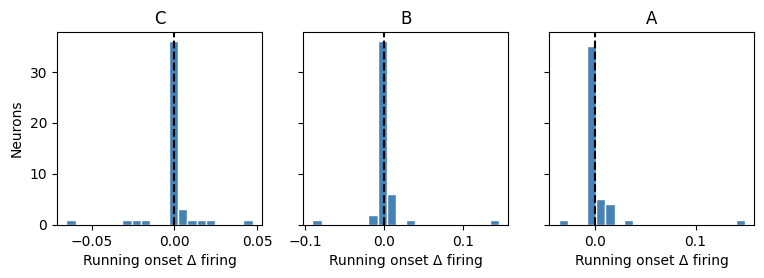

In [25]:
plot_onset_delta(onset_results)

While almost every neuron shows no effect, there are outliers, most notably the right-most outlier in the plots A and B which corresponds to neuron 36. To inspect the mean onset curves for the population and neuron 36, they are plotted below.

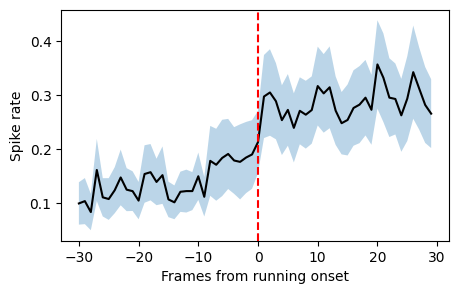

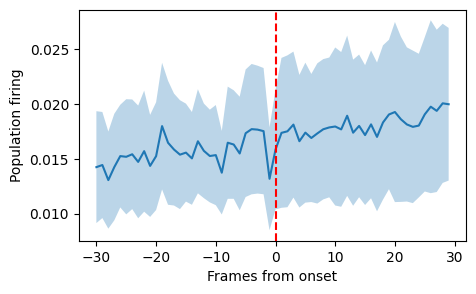

In [26]:
plot_onset_neuron(onset_data, "B", 36)
plot_population_onset(onset_data, "B")

While in the population curve no obvious effect is visible, neuron 36's activity seems to "jump" at onset time.

To give another overview of neural activity at onset time, there is a heatmap below, sorted by activity. Neuron 36 is the upmost neuron.

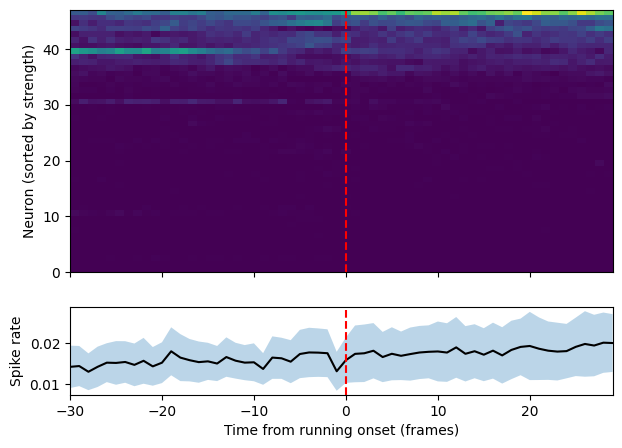

In [27]:
plot_onset_population(
    onset_data,
    "B"
)

# Intermediate Result

Given the limited data, the results of correlational and onset analysis have to be interpreted carefully. However, the analysis suggests that there might be some trends.
1) The average neuron and the majority of neurons seems not to be influenced by running onset or running speed.
2) Some neurons activity might be correlated to running speed (most notably here: neuron 25)
3) Some might be correlated with onsets (most notably here: neuron 36).
4) Some might be modulated slightly positively or negatively by running (correlations of up to -0.3) which could indicate sensory gating for some neurons and activity increase in others
5) Neuron response behaviour in relation to movement is very heterogeneous and probably very individual for single neurons